<a href="https://colab.research.google.com/github/konul-aliyeva/DeepLearning/blob/main/Introduction_to_DeepLearning_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import torch

In [ ]:
A = torch.tensor([
    [1.0, 4.0, 7.0],
    [2.0, 3.0, 6.0]
])


In [ ]:
A


tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [ ]:
X =torch.tensor([
    [1.0, 4.0, 7.0],
    [2.0, 3.0, 6.0]
], dtype=torch.bfloat16)


In [ ]:
X

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.bfloat16)

In [ ]:
X.shape

torch.Size([2, 3])

In [ ]:
X.dtype

torch.bfloat16

NumPy array-ində olduğu kimi, **indexing** və **slicing**-dən istifadə edərək bir tensor-u *in place* dəyişdirə bilərik.

In [ ]:
X[0, 1]

tensor(4., dtype=torch.bfloat16)

In [ ]:
X[:, 1]

tensor([4., 3.], dtype=torch.bfloat16)

In [ ]:
X[:, 1]= -99
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]], dtype=torch.bfloat16)

In [ ]:
X.abs()

tensor([[ 1., 99.,  7.],
        [ 2., 99.,  6.]], dtype=torch.bfloat16)

In [ ]:
torch.abs(X)

tensor([[ 1., 99.,  7.],
        [ 2., 99.,  6.]], dtype=torch.bfloat16)

In [ ]:
# torch.cos(), torch.exp(), torch.max(), torch.mean()

X.sqrt()

tensor([[1.0000,    nan, 2.6406],
        [1.4141,    nan, 2.4531]], dtype=torch.bfloat16)

In [ ]:
10 * (X + 1.0)  # itemwise addition and multiplication

tensor([[  20., -980.,   80.],
        [  30., -980.,   70.]], dtype=torch.bfloat16)

In [ ]:
X.exp()  #torch.exp(X) yazmaq əvəzinə X.exp() yaza bilərik

tensor([[   2.7188,    0.0000, 1096.0000],
        [   7.3750,    0.0000,  404.0000]], dtype=torch.bfloat16)

In [ ]:
X.mean()

tensor(-30.3750, dtype=torch.bfloat16)

In [ ]:
X.max(dim=0)  #keepdim = True
 # max values along dimension 0

torch.return_types.max(
values=tensor([  2., -99.,   7.], dtype=torch.bfloat16),
indices=tensor([1, 0, 0]))

In [ ]:
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]], dtype=torch.bfloat16)

In [ ]:
X @ X.T

tensor([[9856., 9856.],
        [9856., 9856.]], dtype=torch.bfloat16)

In [ ]:
import numpy as np

In [ ]:
A.numpy()


array([[1., 4., 7.],
       [2., 3., 6.]], dtype=float32)

In [ ]:
torch.tensor(np.array([[1.,4., 7.,],
                       [2., 3., 6.,]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.float64)

float-lar üçün default precision *PyTorch-da 32 bit* olduğu halda, NumPy-da 64 bitdir. Deep learning sahəsində adətən 32 bit istifadə etmək daha yaxşıdır, çünki bu, yarıbayarı daha az RAM tutur və hesablamaları sürətləndirir; həmçinin neural net-lər real olaraq 64-bit float-ların təqdim etdiyi əlavə precision-a ehtiyac duymur.

In [ ]:
 #automatically converts the array to 32 bits
N = torch.FloatTensor(np.array([
    [1., 4., 7., ],
    [2., 3., 6]
]))

***torch.from_numpy()*** funksiyasından istifadə NumPy array-ini dəyişdirerken həm də tensor-u dəyişdirəcək və ya əksinə.

In [ ]:
N.dtype

torch.float32

In [ ]:
X.relu()  # relu(x)=max(0,x)

tensor([[1., 0., 7.],
        [2., 0., 6.]], dtype=torch.bfloat16)

In [ ]:
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]], dtype=torch.bfloat16)

In [ ]:
X.relu_()

tensor([[1., 0., 7.],
        [2., 0., 6.]], dtype=torch.bfloat16)

In [ ]:


X  # relu _ underscore changed in place

tensor([[1., 0., 7.],
        [2., 0., 6.]], dtype=torch.bfloat16)

cpu- sequantially  < gpu ise paralel

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else :
  device = "cpu"

In [ ]:
M = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.]
])

M = M.to(device)

cpu() və cuda() method-ları müvafiq olaraq to("cpu") və to("cuda") ifadələrinin qısaldılmış formalarıdır.

In [ ]:
M

tensor([[1., 2., 3.],
        [4., 5., 6.]], device='cuda:0')

In [ ]:
M.device

device(type='cuda', index=0)

In [ ]:
M = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.]],device=device)


In [ ]:
R = M @ M.T

In [ ]:
R

tensor([[14., 32.],
        [32., 77.]], device='cuda:0')

In [ ]:
M =torch.rand((1000, 1000 )) # on the CPU
%timeit M @ M.T
M =torch.rand((1000, 1000 ), device='cuda') # on the GPU
%timeit M @ M.T

16.8 ms ± 2.46 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
572 µs ± 4.01 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
x = torch.tensor(5.0, requires_grad=True)   #
f = x ** 2
f

tensor(25., grad_fn=<PowBackward0>)

In [ ]:
f.backward()
x.grad

tensor(10.)

In [ ]:
learning_rate = 0.1
with torch.no_grad():
  x -= learning_rate * x.grad  #Gradient descent step

In [ ]:
x

tensor(4., requires_grad=True)

In [ ]:
X_detached = x.detach()
X_detached = learning_rate * x.grad

In [ ]:
X_detached

tensor(1.)

In [ ]:
x.grad.zero_()

tensor(0.)

In [ ]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
  f = x ** 2    #forward pass
  f.backward()
  with torch.no_grad():
    x -= learning_rate * x.grad #gradient descent step
    print(x)
    #print(x.grad)

    x.grad.zero_()  # reset the gradients

tensor(4., requires_grad=True)
tensor(3.2000, requires_grad=True)
tensor(2.5600, requires_grad=True)
tensor(2.0480, requires_grad=True)
tensor(1.6384, requires_grad=True)
tensor(1.3107, requires_grad=True)
tensor(1.0486, requires_grad=True)
tensor(0.8389, requires_grad=True)
tensor(0.6711, requires_grad=True)
tensor(0.5369, requires_grad=True)
tensor(0.4295, requires_grad=True)
tensor(0.3436, requires_grad=True)
tensor(0.2749, requires_grad=True)
tensor(0.2199, requires_grad=True)
tensor(0.1759, requires_grad=True)
tensor(0.1407, requires_grad=True)
tensor(0.1126, requires_grad=True)
tensor(0.0901, requires_grad=True)
tensor(0.0721, requires_grad=True)
tensor(0.0576, requires_grad=True)
tensor(0.0461, requires_grad=True)
tensor(0.0369, requires_grad=True)
tensor(0.0295, requires_grad=True)
tensor(0.0236, requires_grad=True)
tensor(0.0189, requires_grad=True)
tensor(0.0151, requires_grad=True)
tensor(0.0121, requires_grad=True)
tensor(0.0097, requires_grad=True)
tensor(0.0077, requires_

In [ ]:
# t = torch.tensor(2.0,requires_grad=True )
# z = t.exp()
# z+=1
# z.backward()

In [ ]:
t = torch.tensor(2.0,requires_grad=True )
z = t.exp()
z=z + 1
z.backward()

In [ ]:
import sklearn

In [ ]:
X,y = sklearn.datasets.fetch_california_housing(return_X_y=True)
X_train_full, X_test, y_train_full, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2)

In [ ]:
X_train, X_valid, y_train, y_valid = sklearn.model_selection.train_test_split(X_train_full, y_train_full, test_size=0.2)

In [ ]:
X_train.shape, X_valid.shape, X_test.shape

((13209, 8), (3303, 8), (4128, 8))

In [ ]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_valid - means) / stds


In [ ]:
y_train = torch.FloatTensor(y_train).reshape(-1,1)
y_valid = torch.FloatTensor(y_valid).reshape(-1,1)
y_test = torch.FloatTensor(y_test).reshape(-1,1)

In [ ]:
torch.manual_seed(42)
n_features = X_train.shape[1]
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)


In [ ]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
  y_pred =X_train @ w + b
  loss = ((y_pred - y_train) ** 2).mean()
  loss.backward()  # her deyisene gore toremeleri tapir w, b
  with torch.no_grad():
    b -= learning_rate * b.grad
    w -= learning_rate * w.grad
    b.grad.zero_()
    w.grad.zero_()
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}')


Epoch 1/20, Loss: 16.091562271118164
Epoch 2/20, Loss: 4.895119667053223
Epoch 3/20, Loss: 2.2648632526397705
Epoch 4/20, Loss: 1.3272420167922974
Epoch 5/20, Loss: 0.9555623531341553
Epoch 6/20, Loss: 0.7970777153968811
Epoch 7/20, Loss: 0.7225431203842163
Epoch 8/20, Loss: 0.6823680996894836
Epoch 9/20, Loss: 0.6570279002189636
Epoch 10/20, Loss: 0.6386598348617554
Epoch 11/20, Loss: 0.6240071654319763
Epoch 12/20, Loss: 0.6116575002670288
Epoch 13/20, Loss: 0.6009490489959717
Epoch 14/20, Loss: 0.5915321111679077
Epoch 15/20, Loss: 0.583192765712738
Epoch 16/20, Loss: 0.5757805705070496
Epoch 17/20, Loss: 0.5691781044006348
Epoch 18/20, Loss: 0.5632883310317993
Epoch 19/20, Loss: 0.5580283403396606
Epoch 20/20, Loss: 0.553325891494751


In [ ]:
X_new =  X_test[:3]
with torch.no_grad():
  y_pred = X_new @ w + b

y_pred

tensor([[-12.7711],
        [-12.3255],
        [-11.9185]])

In [ ]:
y_test[:3]

tensor([[1.0110],
        [0.6220],
        [1.8390]])

In [ ]:
import torch.nn as nn

In [ ]:
torch.manual_seed(42)
model = nn.Linear(in_features = n_features, out_features=1)


In [ ]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [ ]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [ ]:
model.parameters()

<generator object Module.parameters at 0x7e5ddb5c4ba0>

In [ ]:
next(model.parameters())

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [ ]:
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [ ]:
for name, param in model.named_parameters():
  print(f'{name} |{param}')

weight |Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
bias |Parameter containing:
tensor([0.3117], requires_grad=True)


In [ ]:
model(X_train[:2])

tensor([[-0.1185],
        [ 0.5892]], grad_fn=<AddmmBackward0>)

In [ ]:
y_train[:2]

tensor([[2.8750],
        [1.1930]])

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss

In [ ]:
model(X_train[:2])

tensor([[-0.1185],
        [ 0.5892]], grad_fn=<AddmmBackward0>)

In [ ]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
 for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}')



In [ ]:
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.234048366546631
Epoch 2/20, Loss: 0.7553889751434326
Epoch 3/20, Loss: 0.6055356860160828
Epoch 4/20, Loss: 0.5872530937194824
Epoch 5/20, Loss: 0.5773512125015259
Epoch 6/20, Loss: 0.5694493055343628
Epoch 7/20, Loss: 0.5627170205116272
Epoch 8/20, Loss: 0.5568581819534302
Epoch 9/20, Loss: 0.5517128109931946
Epoch 10/20, Loss: 0.5471742749214172
Epoch 11/20, Loss: 0.5431618094444275
Epoch 12/20, Loss: 0.5396093726158142
Epoch 13/20, Loss: 0.5364606380462646
Epoch 14/20, Loss: 0.5336674451828003
Epoch 15/20, Loss: 0.5311873555183411
Epoch 16/20, Loss: 0.5289834141731262
Epoch 17/20, Loss: 0.5270233750343323
Epoch 18/20, Loss: 0.525278627872467
Epoch 19/20, Loss: 0.523724377155304
Epoch 20/20, Loss: 0.5223384499549866


# Making it MiniBatches


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_dataset = TensorDataset(X_train, y_train)

In [ ]:
train_loader =DataLoader(train_dataset, batch_size=32, shuffle=True)


In [ ]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(in_features= n_features, out_features= 64),
    nn.ReLU(),
    nn.Linear(in_features= 64, out_features= 32),
    nn.ReLU(),
    nn.Linear(in_features= 32, out_features= 1)
)

model.to(device)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr= learning_rate)
mse = nn.MSELoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0.
    for X_batch,y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred =  model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss:{mean_loss:.4f}')

In [ ]:

train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss:0.6511
Epoch 2/20, Loss:0.4224
Epoch 3/20, Loss:0.3974
Epoch 4/20, Loss:0.3840
Epoch 5/20, Loss:0.3741
Epoch 6/20, Loss:0.3655
Epoch 7/20, Loss:0.3539
Epoch 8/20, Loss:0.3486
Epoch 9/20, Loss:0.3433
Epoch 10/20, Loss:0.3359
Epoch 11/20, Loss:0.3320
Epoch 12/20, Loss:0.3386
Epoch 13/20, Loss:0.3245
Epoch 14/20, Loss:0.3195
Epoch 15/20, Loss:0.3165
Epoch 16/20, Loss:0.3159
Epoch 17/20, Loss:0.3090
Epoch 18/20, Loss:0.3103
Epoch 19/20, Loss:0.3055
Epoch 20/20, Loss:0.3029


In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
# LET'S EVALUATE our model

def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
  model.eval()
  metrics=[]
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric = metric_fn(y_pred, y_batch)

    metrics.append(metric)
  return aggregate_fn(torch.stack(metrics))

In [ ]:
valid_dataset = TensorDataset(X_valid,y_valid)
valid_loader = DataLoader(valid_dataset, batch_size= 32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

In [ ]:
def rmse(y_pred, y_true):
  return ((y_pred - y_true) ** 2).mean().sqrt()

In [ ]:
evaluate(model, valid_loader, rmse)

In [ ]:
0.3269 **0.5 != 0.5619

The reason is that instead of calculating the RMSE over the whole validation set, we computed it over each batch and then computed the mean of all these batch RMSEs

In [ ]:
evaluate(model, valid_loader, mse,
         aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

In [ ]:
0.3149 ** 0.5

In [ ]:
%pip install torchmetrics

In [ ]:
import torchmetrics

In [ ]:
def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch)
  return metric.compute()



In [ ]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model, valid_loader, rmse)

tensor(0.6049, device='cuda:0')

# Deep and Wide Networks

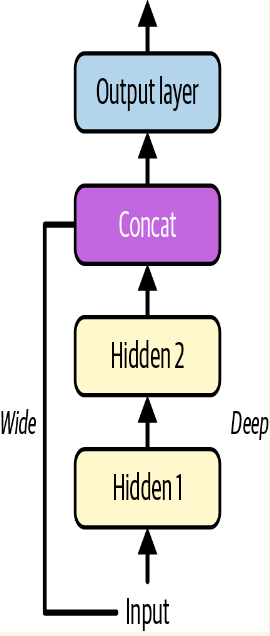

In [ ]:
class WideAndDeep(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = Sequential(
        nn.Linear(n_features, 50),
        nn.ReLU(),
        nn.Linear(50, 40),
        nn.ReLU(),
    )

    self.output_layer = nn.Linear(40 + n_features, 1)

  def forward(self, X):
    deep_output = self.deep_stack(X)
    wide_and_deep = torch.concat([X,deep_output], dim=1)
    return self.output_layer(wide_and_deep)

In [ ]:
[i for i in WideAndDeep(8).children()]

[Sequential(
   (0): Linear(in_features=8, out_features=50, bias=True)
   (1): ReLU()
   (2): Linear(in_features=50, out_features=40, bias=True)
   (3): ReLU()
 ),
 Linear(in_features=48, out_features=1, bias=True)]

In [ ]:
[i for i in WideAndDeep(8).named_children()]

[('deep_stack',
  Sequential(
    (0): Linear(in_features=8, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )),
 ('output_layer', Linear(in_features=48, out_features=1, bias=True))]

In [ ]:
torch.manual_seed(42)
model =WideAndDeep(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)
mse= nn.MSELoss()

NameError: name 'torch' is not defined

In [ ]:
class WideAndDeepV2(nn.Module):
  def __init__(self, n_features):
    super().__init__()

    self.deep_stack = nn.Sequential(
        nn.Linear(n_features - 2, 50), # X_deep = X[:, 2:]
        nn.ReLU(),
        nn.Linear(50, 40),
        nn.ReLU()
        )

    self.output_layer = nn.Linear(40 + 5, 1)      # 5 comes from wide


  def forward(self, X):
    X_wide = X[:, :5]
    X_deep = X[:, 2:]


    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim=1)

    return self.output_layer(wide_and_deep)

In [ ]:
torch.manual_seed(42)
model = WideAndDeepV2(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss:1.3866
Epoch 2/20, Loss:0.6026
Epoch 3/20, Loss:0.5496
Epoch 4/20, Loss:0.5185
Epoch 5/20, Loss:0.4985
Epoch 6/20, Loss:0.4846
Epoch 7/20, Loss:0.4745
Epoch 8/20, Loss:0.4662
Epoch 9/20, Loss:0.4598
Epoch 10/20, Loss:0.4544
Epoch 11/20, Loss:0.4495
Epoch 12/20, Loss:0.4451
Epoch 13/20, Loss:0.4414
Epoch 14/20, Loss:0.4378
Epoch 15/20, Loss:0.4354
Epoch 16/20, Loss:0.4320
Epoch 17/20, Loss:0.4302
Epoch 18/20, Loss:0.4275
Epoch 19/20, Loss:0.4252
Epoch 20/20, Loss:0.4233


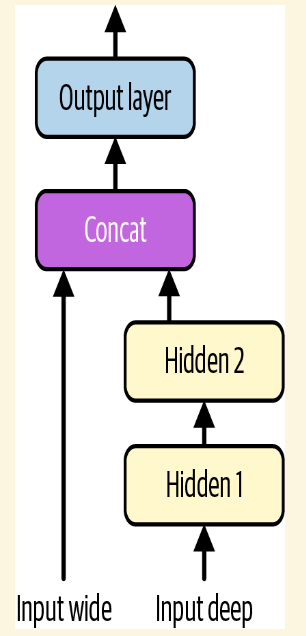


In [ ]:
class WideAndDeepV3(nn.Module):
  def __init__(self, n_features):
    super().__init__()

    self.deep_stack = nn.Sequential(
        nn.Linear(n_features - 2, 50), nn.ReLU(),   # 6 features left
        nn.Linear(50, 40), nn.ReLU()
    )
    self.output_layer = nn.Linear(40 + 5, 1)   # 5 comes from wide

  def forward(self, X_wide, X_deep):
    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim=1)

    return self.output_layer(wide_and_deep)

In [ ]:
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)

train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32, shuffle=True)
test_loader_wd = DataLoader(test_data_wd, batch_size=32, shuffle=True)

AssertionError: Size mismatch between tensors

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    total_loss = 0.
    for X_batch_wide, X_batch_deep, y_batch in train_loader:
      X_batch_wide, X_batch_deep, y_batch = X_batch_wide.to(device), X_batch_deep.to(device), y_batch.to(device)
      y_pred = model(X_batch_wide, X_batch_deep)
      loss = criterion(y_pred, y_batch)
      total_loss = total_loss + loss
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss:{mean_loss:.4f}')

In [ ]:
torch.manual_seed(42)
learning_rate= 0.02
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse=nn.MSELoss()
train(model, optimizer, mse, train_loader_wd, n_epochs)

Epoch 1/20, Loss:0.6154
Epoch 2/20, Loss:0.4644
Epoch 3/20, Loss:0.4263
Epoch 4/20, Loss:0.4108
Epoch 5/20, Loss:0.4062
Epoch 6/20, Loss:0.3876
Epoch 7/20, Loss:0.3818
Epoch 8/20, Loss:0.3687
Epoch 9/20, Loss:0.3563
Epoch 10/20, Loss:0.3506
Epoch 11/20, Loss:0.3527
Epoch 12/20, Loss:0.3430
Epoch 13/20, Loss:0.3403
Epoch 14/20, Loss:0.3379
Epoch 15/20, Loss:0.3415
Epoch 16/20, Loss:0.3341
Epoch 17/20, Loss:0.3281
Epoch 18/20, Loss:0.3328
Epoch 19/20, Loss:0.3268
Epoch 20/20, Loss:0.3278


In [ ]:
class WideAndDeepDataset(torch.utils.data.Dataset):
  def __init__(self, X_wide, X_deep, y):
    self.X_wide = X_wide
    self.X_deep = X_deep
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
    return input_dict, self.y[idx]


In [ ]:
train_data_named = WideAndDeepDataset(X_wide = X_train[:, :5], X_deep = X_train[:, 2:], y=y_train)
valid_data_named = WideAndDeepDataset(X_wide = X_valid[:, :5], X_deep = X_valid[:, 2:], y=y_valid)
test_data_named = WideAndDeepDataset(X_wide = X_test[:, :5], X_deep = X_test[:, 2:], y=y_test)

train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)
test_loader_named = DataLoader(test_data_named, batch_size=32)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs, plot_loss=False):
  losses = []
  for epoch in range(n_epochs):
    for inputs, y_batch in train_loader:
      inputs = {name: X.to(device) for name, X in inputs.items()}
      y_batch = y_batch.to(device)
      y_pred = model(X_wide=inputs['X_wide'], X_deep=inputs['X_deep'])
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    losses.append(loss.item())
    print(f'Epoch {epoch + 1}/{n_epochs}, Loss: {loss}')

  if plot_loss:
    plt.figure(figsize=(8, 5))
    plt.title('Learning Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(range(n_epochs),losses);

Epoch 1/20, Loss: 0.2829801142215729
Epoch 2/20, Loss: 0.3277747929096222
Epoch 3/20, Loss: 0.2708030045032501
Epoch 4/20, Loss: 0.76540607213974
Epoch 5/20, Loss: 0.5235147476196289
Epoch 6/20, Loss: 0.21015483140945435
Epoch 7/20, Loss: 0.45254141092300415
Epoch 8/20, Loss: 0.6201539635658264
Epoch 9/20, Loss: 0.2404644787311554
Epoch 10/20, Loss: 0.32765600085258484
Epoch 11/20, Loss: 0.19239436089992523
Epoch 12/20, Loss: 0.33181846141815186
Epoch 13/20, Loss: 0.6102290153503418
Epoch 14/20, Loss: 0.20853187143802643
Epoch 15/20, Loss: 0.3383499085903168
Epoch 16/20, Loss: 0.3876587152481079
Epoch 17/20, Loss: 0.34495437145233154
Epoch 18/20, Loss: 0.16775383055210114
Epoch 19/20, Loss: 0.19259563088417053
Epoch 20/20, Loss: 0.17028163373470306


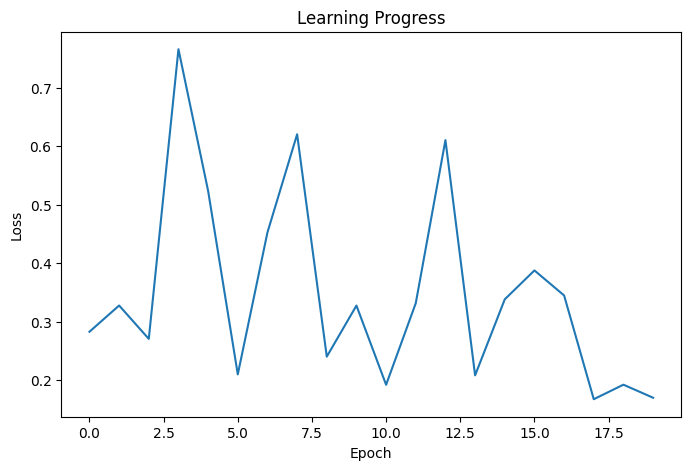

In [ ]:
lr = 0.005
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
mse = nn.MSELoss()

In [ ]:
model = model.to(device)

In [ ]:
train(model, optimizer, mse, train_loader_named, 20, True)

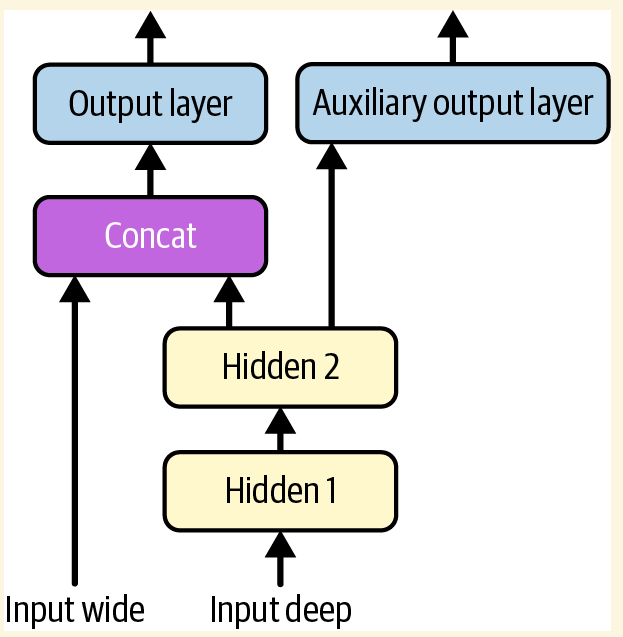

In [ ]:
class WideAndDeepV4(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(6, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU()
    )
    self.output_layer = nn.Linear(40 + 5, 1)
    self.aux_output_layer = nn.Linear(40, 1)

  def forward(self, X_wide, X_deep):
    deep_output = self.deep_stack(X_deep)
    concat = torch.concat([X_wide, deep_output], dim=1)
    main_output = self.output_layer(concat)
    aux_output = self.aux_output_layer(deep_output)

    return main_output, aux_output


In [ ]:
model = WideAndDeepV4(n_features)

In [ ]:
model

WideAndDeepV4(
  (deep_stack): Sequential(
    (0): Linear(in_features=6, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=45, out_features=1, bias=True)
  (aux_output_layer): Linear(in_features=40, out_features=1, bias=True)
)

In [ ]:
!pip install torchviz graphviz

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    for inputs, y_batch in train_loader:
      y_pred, y_pred_aux = model(**inputs)
      main_loss = criterion(y_pred, y_batch)
      aux_loss = criterion(y_pred_aux, y_batch)
      loss = 0.8 * main_loss + 0.2 * aux_loss

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    print(f'Epoch {epoch + 1}/{n_epochs}, Loss: {loss}')

In [ ]:
lr = 0.005
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
mse = nn.MSELoss()

In [ ]:
train(model, optimizer, mse, train_loader_named, 20)

Epoch 1/20, Loss: 0.7469655275344849
Epoch 2/20, Loss: 0.6794363856315613
Epoch 3/20, Loss: 0.6531512141227722
Epoch 4/20, Loss: 0.5507308840751648
Epoch 5/20, Loss: 0.3637423515319824
Epoch 6/20, Loss: 0.522628128528595
Epoch 7/20, Loss: 0.6812089085578918
Epoch 8/20, Loss: 0.4346928894519806
Epoch 9/20, Loss: 0.2458474040031433
Epoch 10/20, Loss: 0.21244317293167114
Epoch 11/20, Loss: 0.3251771926879883
Epoch 12/20, Loss: 0.7092695236206055
Epoch 13/20, Loss: 0.8504917025566101
Epoch 14/20, Loss: 0.6646506786346436
Epoch 15/20, Loss: 0.14162178337574005
Epoch 16/20, Loss: 0.2959510087966919
Epoch 17/20, Loss: 0.5660581588745117
Epoch 18/20, Loss: 0.62362140417099
Epoch 19/20, Loss: 0.39825958013534546
Epoch 20/20, Loss: 0.1690148115158081


In [ ]:
X_wide_graph = [i for i in train_loader_named][:1][0][0]['X_wide']
X_deep_graph = [i for i in train_loader_named][:1][0][0]['X_deep']

In [ ]:

import torch
from torchviz import make_dot
import torchvision.models as models

In [ ]:
model.eval()

batch_size = 1
X_wide = torch.zeros(batch_size, 5)
X_deep = torch.zeros(batch_size, 6)

y_pred, y_aux = model(X_wide, X_deep)

dot = make_dot(
    (y_pred + y_aux).sum(),
    params=dict(model.named_parameters())
)

dot.format = "png"
dot.render("wide_and_deep_graph")


'wide_and_deep_graph.png'

# Let's do some VISION👁

In [ ]:
import torchvision
import torchvision.transforms.v2 as T

In [ ]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [ ]:
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='datasets', train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root='datasets', train=False, download=True, transform=toTensor)

In [ ]:
torch.manual_seed(42)

In [ ]:
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data,
                                                       [55_000, 5_000])

In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)


In [ ]:
X_sample, y_sample = train_data[0]

In [ ]:
X_sample.dtype

torch.float32

In [ ]:
X_sample.shape

torch.Size([1, 28, 28])

In [ ]:
train_and_valid_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class ImageClassifier(nn.Module):
  def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Flatten(),
        nn.Linear(n_inputs, n_hidden1),
        nn.ReLU(),
        nn.Linear(n_hidden1, n_hidden2),
        nn.ReLU(),
        nn.Linear(n_hidden2, n_classes),
    )

  def forward(self, X):
    return self.mlp(X)

In [ ]:
torch.manual_seed(42)

In [ ]:
model = ImageClassifier(n_inputs=28*28, n_hidden1=300, n_hidden2=100, n_classes=10)
model = model.to(device)
xentropy = nn.CrossEntropyLoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  for epoch in range(n_epochs):
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    print(f'Epoch: {epoch+1}/{n_epochs}, Loss: {loss}')

In [ ]:
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.002)

In [ ]:
train(model, optimizer, xentropy, train_loader, 20)

Epoch: 1/20, Loss: 2.3152263164520264
Epoch: 2/20, Loss: 2.325509786605835
Epoch: 3/20, Loss: 2.322967529296875
Epoch: 4/20, Loss: 2.2849209308624268
Epoch: 5/20, Loss: 2.3055410385131836
Epoch: 6/20, Loss: 2.308236837387085
Epoch: 7/20, Loss: 2.325643539428711
Epoch: 8/20, Loss: 2.3125574588775635
Epoch: 9/20, Loss: 2.312513589859009
Epoch: 10/20, Loss: 2.29607892036438
Epoch: 11/20, Loss: 2.3331143856048584
Epoch: 12/20, Loss: 2.310720443725586
Epoch: 13/20, Loss: 2.3027515411376953
Epoch: 14/20, Loss: 2.3049120903015137
Epoch: 15/20, Loss: 2.324148654937744
Epoch: 16/20, Loss: 2.3035333156585693
Epoch: 17/20, Loss: 2.3219282627105713
Epoch: 18/20, Loss: 2.327850341796875
Epoch: 19/20, Loss: 2.3069262504577637
Epoch: 20/20, Loss: 2.3225433826446533


In [ ]:
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

In [ ]:
model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [ ]:
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)

with torch.no_grad():
  y_pred_logits = model(X_new)

y_pred = y_pred_logits.argmax(dim=1)
y_pred

tensor([5, 5, 5], device='cuda:0')

In [ ]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sandal', 'Sandal', 'Sandal']

In [ ]:
X_new.shape

torch.Size([3, 1, 28, 28])

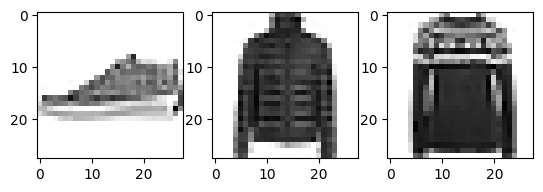

In [ ]:
for i in range(X_new.shape[0]):
  plt.subplot(1, 3, i +1)
  plt.imshow(X_new[i, 0, :, :].cpu().numpy(), cmap='gray')

In [ ]:
import torch.nn.functional as F

In [ ]:
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.1040, 0.1010, 0.0960, 0.0950, 0.1010, 0.1060, 0.1010, 0.0930, 0.0990,
         0.1030],
        [0.1020, 0.1000, 0.0990, 0.0970, 0.0930, 0.1150, 0.1000, 0.0960, 0.1000,
         0.0970],
        [0.1010, 0.1040, 0.0990, 0.0920, 0.0940, 0.1160, 0.0970, 0.0970, 0.1010,
         0.0990]], device='cuda:0')

In [ ]:
y_top4_logits, y_top4_indices = torch.topk(y_pred_logits, 4, dim=1)
y_top4_probas = F.softmax(y_top4_logits, dim=1)
y_top4_probas.round(decimals=3)


tensor([[0.2550, 0.2510, 0.2490, 0.2440],
        [0.2750, 0.2450, 0.2400, 0.2400],
        [0.2740, 0.2470, 0.2400, 0.2390]], device='cuda:0')

In [ ]:
y_top4_indices


tensor([[5, 0, 9, 1],
        [5, 0, 1, 6],
        [5, 1, 0, 8]], device='cuda:0')

# Optimizing Models

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.5 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [ ]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

In [ ]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-02-07 16:30:20,424] A new study created in memory with name: no-name-6d074803-67c3-405b-becd-5004f1941cd1


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5562
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 6/10, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 7/10, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6326
Epoch 8/10, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 9/10, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6424


[I 2026-02-07 16:33:01,510] Trial 0 finished with value: 0.6435999870300293 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


Epoch 10/10, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/10, train loss: 1.1459, train metric: 0.6229, valid metric: 0.7338
Epoch 2/10, train loss: 0.6108, train metric: 0.7841, valid metric: 0.7992
Epoch 3/10, train loss: 0.5203, train metric: 0.8169, valid metric: 0.8094
Epoch 4/10, train loss: 0.4810, train metric: 0.8302, valid metric: 0.8310
Epoch 5/10, train loss: 0.4557, train metric: 0.8404, valid metric: 0.8352
Epoch 6/10, train loss: 0.4387, train metric: 0.8460, valid metric: 0.8442
Epoch 7/10, train loss: 0.4240, train metric: 0.8512, valid metric: 0.8408
Epoch 8/10, train loss: 0.4123, train metric: 0.8566, valid metric: 0.8514
Epoch 9/10, train loss: 0.3998, train metric: 0.8601, valid metric: 0.8532


[I 2026-02-07 16:35:35,569] Trial 1 finished with value: 0.8547999858856201 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8547999858856201.


...

Epoch 10/10, train loss: 2.2414, train metric: 0.2299, valid metric: 0.2334
Epoch 1/10, train loss: 2.3035, train metric: 0.1373, valid metric: 0.1526
Epoch 2/10, train loss: 2.3005, train metric: 0.1569, valid metric: 0.1724
Epoch 3/10, train loss: 2.2975, train metric: 0.1755, valid metric: 0.1896
Epoch 4/10, train loss: 2.2945, train metric: 0.1941, valid metric: 0.2132
Epoch 5/10, train loss: 2.2914, train metric: 0.2105, valid metric: 0.2288
Epoch 6/10, train loss: 2.2884, train metric: 0.2261, valid metric: 0.2418
Epoch 7/10, train loss: 2.2853, train metric: 0.2419, valid metric: 0.2580
Epoch 8/10, train loss: 2.2823, train metric: 0.2581, valid metric: 0.2742
Epoch 9/10, train loss: 2.2792, train metric: 0.2736, valid metric: 0.2918


[I 2026-02-07 16:40:38,160] Trial 3 finished with value: 0.30959999561309814 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8547999858856201.


Epoch 10/10, train loss: 2.2761, train metric: 0.2897, valid metric: 0.3096
Epoch 1/10, train loss: 1.8379, train metric: 0.4869, valid metric: 0.6208
Epoch 2/10, train loss: 0.9751, train metric: 0.6666, valid metric: 0.6978
Epoch 3/10, train loss: 0.7608, train metric: 0.7253, valid metric: 0.7416
Epoch 4/10, train loss: 0.6704, train metric: 0.7639, valid metric: 0.7720
Epoch 5/10, train loss: 0.6108, train metric: 0.7913, valid metric: 0.7906
Epoch 6/10, train loss: 0.5687, train metric: 0.8053, valid metric: 0.8050
Epoch 7/10, train loss: 0.5386, train metric: 0.8164, valid metric: 0.8082
Epoch 8/10, train loss: 0.5158, train metric: 0.8243, valid metric: 0.8214
Epoch 9/10, train loss: 0.4988, train metric: 0.8279, valid metric: 0.8220


[I 2026-02-07 16:43:09,679] Trial 4 finished with value: 0.8220000267028809 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8547999858856201.


Epoch 10/10, train loss: 0.4842, train metric: 0.8330, valid metric: 0.8092


In [ ]:
study.best_params

In [ ]:
study.best_value

In [ ]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    best_validation_accuracy = 0.0
    for epoch in range(n_epochs):
        history = train2(model, optimizer, xentropy, accuracy, train_loader,
                         valid_loader, n_epochs=1)
        validation_accuracy = max(history["valid_metrics"])
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
        trial.report(validation_accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_validation_accuracy

In [ ]:
objective_with_data = lambda trial: objective(
    trial, train_loader=train_loader, valid_loader=valid_loader)

In [ ]:
from functools import partial

objective_with_data = partial(objective, train_loader=train_loader,
                              valid_loader=valid_loader)

In [ ]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction="maximize", sampler=sampler,
                            pruner=pruner)
study.optimize(objective_with_data, n_trials=20)

In [ ]:
study.best_value

In [ ]:
study.best_params

In [ ]:
torch.save(model, "my_fashion_mnist.pt")


In [ ]:
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)
loaded_model.eval()


In [ ]:
y_pred_logits = loaded_model(X_new)


In [ ]:
torch.save(model.state_dict(), "my_fashion_mnist_weights.pt")


In [ ]:
model.state_dict()

In [ ]:
type(model.state_dict())

In [ ]:
new_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                            n_classes=10)
loaded_weights = torch.load("my_fashion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

In [ ]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 300,
        "n_hidden2": 100,
        "n_classes": 10,
    }
}
torch.save(model_data, "my_fashion_mnist_model.pt")

In [ ]:
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()






> # Compile And Optimize the model



In [ ]:
torchscript_model = torch.jit.trace(model, X_new)

In [ ]:
torchscript_model = torch.jit.script(model)

In [ ]:
optimized_model = torch.jit.optimize_for_inference(torchscript_model)

In [ ]:
optimized_model.save("my_fashion_mnist_torchscript.pt")

In [ ]:
loaded_torchscript_model = torch.jit.load("my_fashion_mnist_torchscript.pt")

In [ ]:
y_pred_logits = loaded_torchscript_model(X_new)
y_pred_logits

In [ ]:
compiled_model = torch.compile(model)

In [ ]:
if device == "cuda":
    y_pred_logits = compiled_model(X_new)